cluster_data/05jun/3.00/1.00
occupancies_t shape: (888, 3, 3000)
w: 93


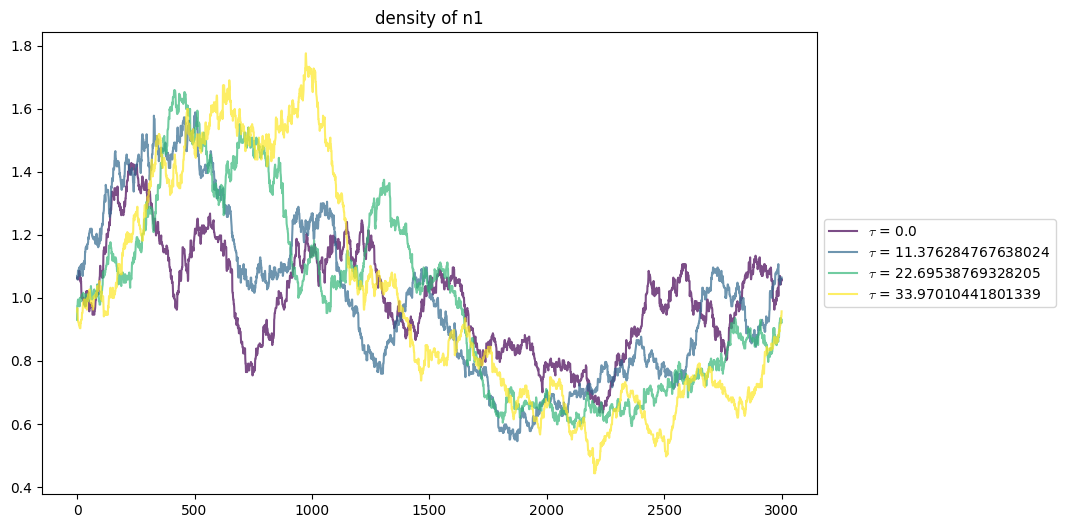

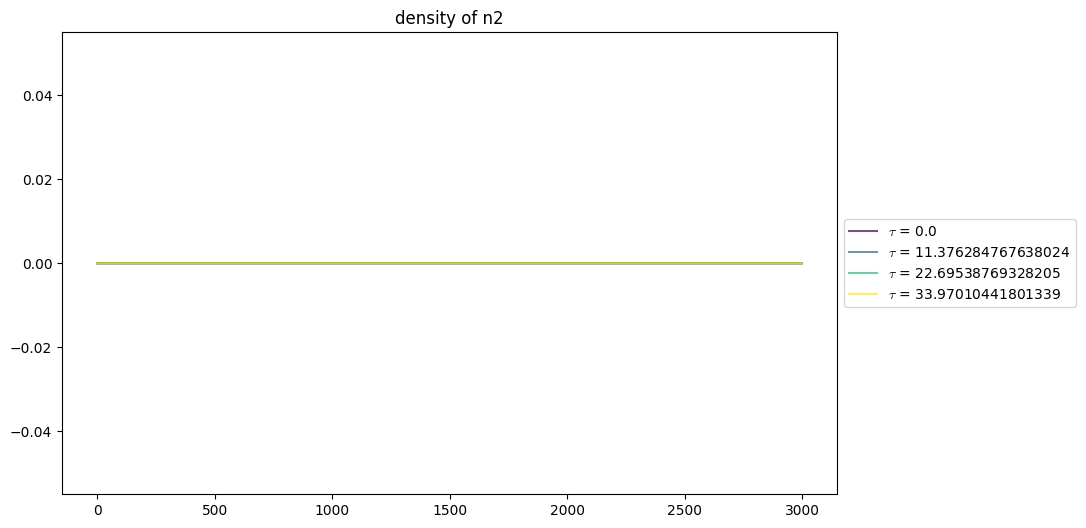

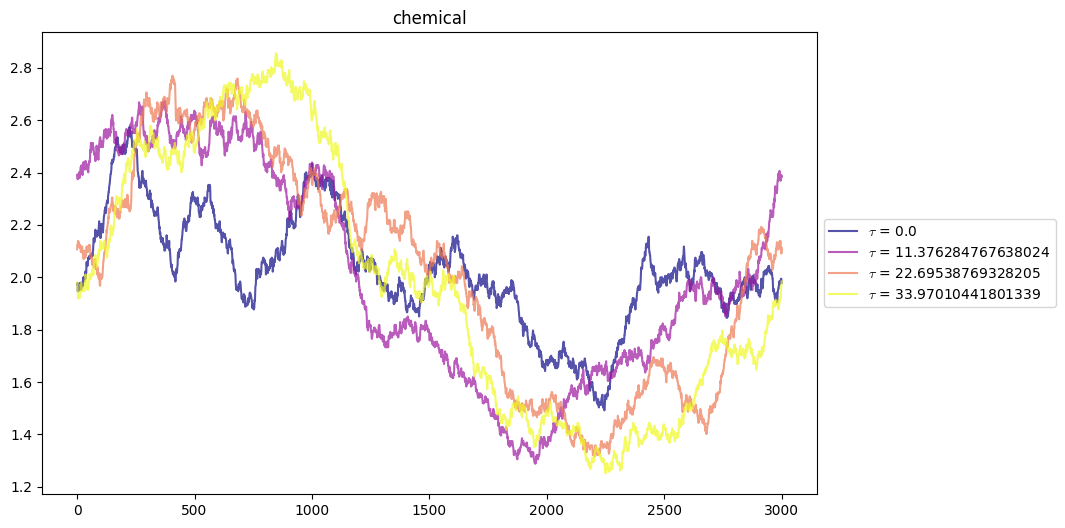

In [6]:
from helper_functions import *
# path = files[8]
path = 'cluster_data/05jun/3.00/1.00'
print(path)
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2]) // 32
print('occupancies_t shape:', occupancies_t.shape)
print('w:', w)
plot_results(occupancies_t, tau_t, w, 0.2, 0.4, 4)

In [7]:
import numpy as np
from scipy.ndimage import uniform_filter1d

def meso_avg_conv(occupancies, w):
    kernel = np.ones(2 * w + 1, dtype=float) / (2 * w + 1)

    # pad periodically
    padded = np.concatenate([
        occupancies[-w:],
        occupancies,
        occupancies[:w]
    ])

    return np.convolve(padded, kernel, mode='valid')

def meso_avg_fft(occupancies, w):
    return uniform_filter1d(
        occupancies.astype(float),
        size=2*w+1,
        mode='wrap'
    )

In [8]:
kymo_p = np.zeros((occupancies_t.shape[0], occupancies_t.shape[2]))
kymo_c = np.zeros((occupancies_t.shape[0], occupancies_t.shape[2]))

for i in range(occupancies_t.shape[0]):
    kymo_p[i] = meso_avg_fft(occupancies_t[i, 0, :], kymo_p[i].shape[0] // 32)
    kymo_c[i] = meso_avg_fft(occupancies_t[i, 2, :], kymo_c[i].shape[0] // 32)


row_means = kymo_p.mean(axis=1, keepdims=True)  # shape (T, 1)
kymo_p /= row_means
row_means = kymo_c.mean(axis=1, keepdims=True)  # shape (T, 1)
kymo_c /= row_means

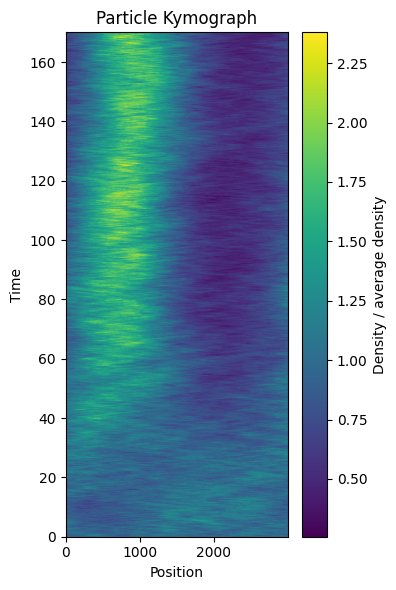

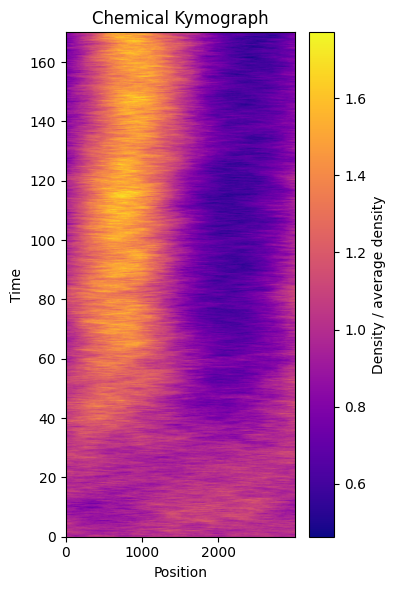

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 6))
plt.imshow(
    kymo_p,
    aspect='auto',
    origin='lower',   # time increases upward
    cmap='viridis',
        extent=[0, kymo_p.shape[1]-1, tau_t[0], tau_t[-1]],
)

plt.xlabel('Position')
plt.ylabel('Time')
plt.colorbar(label='Density / average density')
plt.title('Particle Kymograph')
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 6))
plt.imshow(
    kymo_c,
    aspect='auto',
    origin='lower',   # time increases upward
    cmap='plasma',
        extent=[0, kymo_c.shape[1]-1, tau_t[0], tau_t[-1]],
)

plt.xlabel('Position')
plt.ylabel('Time')
plt.colorbar(label='Density / average density')
plt.title('Chemical Kymograph')
plt.tight_layout()
plt.show()

In [10]:
N = 1000
maxima = np.zeros(N)

for i in range(N):
    maxima[i] = np.max(meso_avg(occupancies_t[-1,0,:], i))

Text(0.5, 1.0, 'Convergence of hydrodynamic limit (max peak height wrt average window size)')

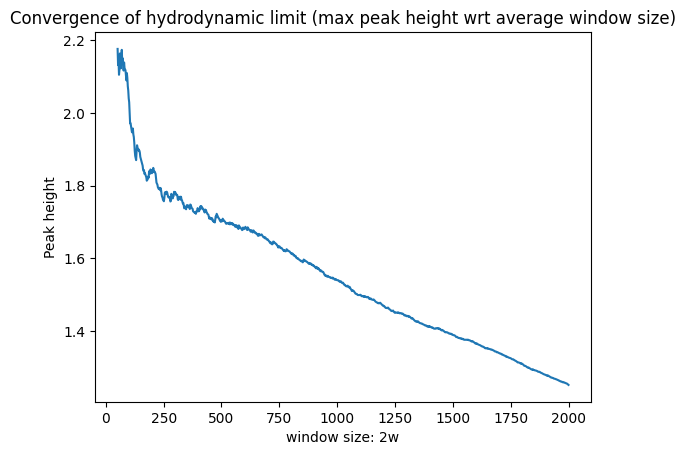

In [11]:
plt.plot(np.linspace(1, N * 2, N)[25:], maxima[25:])
plt.xlabel('window size: 2w')
plt.ylabel('Peak height')
plt.title('Convergence of hydrodynamic limit (max peak height wrt average window size)')

In [12]:
np.mean(occupancies_t[-1, 0:]), np.var(occupancies_t[-1, 0,:])

(np.float64(0.9968888888888889), np.float64(2.354))

(888, 3, 3000)

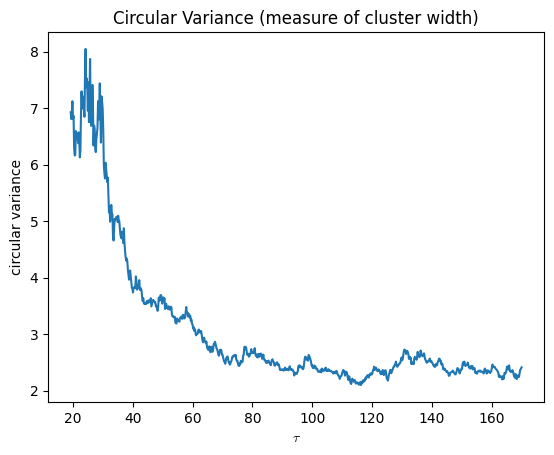

In [13]:
Nsites = occupancies_t.shape[2]

discrete_wave = np.array([np.exp((2 * np.pi / occupancies_t.shape[2]) * i * 1j) for i in range(occupancies_t.shape[2])])

product =  discrete_wave * occupancies_t[:, 0, :]
m1 = np.sum(product, axis=1) / np.sum(occupancies_t[:, 0, :], axis=1)
circle_variances = -2 * np.log(np.abs(m1))
plt.plot(tau_t[100:], circle_variances[100:])
plt.xlabel(fr'$\tau$')
plt.ylabel('circular variance')
plt.title('Circular Variance (measure of cluster width)')
occupancies_t.shape

In [23]:
(3 - circle_variances[-1]) / 120 / circle_variances[-1]

np.float64(0.002026111388147168)

first averge with window w
then CV
then plot CV as function of w

indeed we are more interested in 

Really we want to do this on an average CV to smooth it out

Discussion on Jun16th

Text(0, 0.5, 'Cluster width in number of sites')

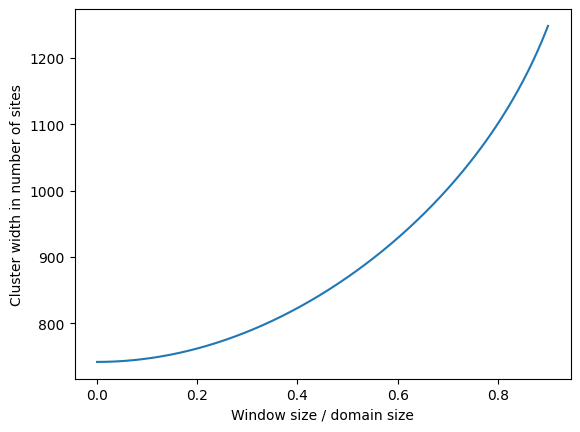

In [15]:
Nws = int(1500 * 0.9)
Nsites = occupancies_t.shape[2]

meso_rho = np.zeros((Nws, Nsites))
cvs = np.zeros((Nws))
rho = occupancies_t[-1,0,:]

discrete_wave = np.array([np.exp((2 * np.pi / occupancies_t.shape[2]) * i * 1j) for i in range(occupancies_t.shape[2])])

for w in range(Nws):
    meso_rho = meso_avg(rho, w)
    product =  discrete_wave * meso_rho
    m1 = np.sum(product) / np.sum(meso_rho)
    cvs[w] = -2 * np.log(np.abs(m1))

plt.plot(np.linspace(0, Nws* 2 / Nsites, Nws) , np.sqrt(cvs) * Nsites / 2 / np.pi)
plt.xlabel('Window size / domain size')
plt.ylabel('Cluster width in number of sites')

In [16]:
s = 0.95
e = 1
Nt = occupancies_t.shape[0]
rho = occupancies_t[int(Nt*s):int(Nt*e), 0, :]

_, L = rho.shape

print(rho.shape)

rho_centered = np.empty_like(rho)

for i in range(rho.shape[0]):
    peak = np.argmax(rho[i])
    shift = L // 2 - peak
    rho_centered[i] = np.roll(rho[i], shift)

rho = rho_centered

# remove DC mode per run (crucial)
rho_fluct = rho - rho.mean(axis=1, keepdims=True)

rhok = np.fft.fft(rho_fluct, axis=1)

#structure factor
Sk = np.mean(np.abs(rhok)**2, axis=0) / L**2

ks = np.fft.fftshift(2*np.pi*np.fft.fftfreq(L))
Sk = np.fft.fftshift(Sk)

Sk_norm = Sk / Sk.max()

above = np.where(Sk_norm >= 0.5)[0]

fwhm_k = ks[above[-1]] - ks[above[0]]
xi = 2*np.pi / fwhm_k
xi

(45, 3000)


np.float64(1500.0000000000002)

In [17]:
ks = 2 * np.pi * np.fft.fftfreq(L)

print("S(0) =", Sk[0])
print("mean S(k>0) =", np.mean(Sk[1:]))
print("max S(k>0) =", np.max(Sk[1:]))

S(0) = 0.0006094814814814815
mean S(k>0) = 0.0008342576414360343
max S(k>0) = 0.0994710986689093


Using ornstein zernicke fit:

In [18]:
rho_fluct = rho - rho.mean(axis=1, keepdims=True)

rhok = np.fft.fft(rho_fluct, axis=1)
Sk = np.mean(np.abs(rhok)**2, axis=0) / L

ks = 2 * np.pi * np.fft.fftfreq(L)

# center both consistently
ks = np.fft.fftshift(ks)
Sk = np.fft.fftshift(Sk)

# FWHM
Sk_norm = Sk / Sk.max()
above = np.where(Sk_norm >= 0.5)[0]

fwhm_k = ks[above[-1]] - ks[above[0]]
xi = np.sqrt(-np.polyfit(ks[ks>0][:5]**2, Sk[ks>0][:5]/Sk.max(), 1)[0])
print("xi =", xi)

xi = 78.99881599822926


Structure factor with diagnostics

k_peak = 0.0020943951023931952
correlation length ξ ≈ nan
>>> No finite-k peak → homogeneous or critical fluctuations
high-k slope ≈ -0.48506299669117514


/var/folders/tw/wwds8prs35n99xx6b_5911sh0000gn/T/ipykernel_18594/3853833741.py:41: RuntimeWarning: invalid value encountered in sqrt
  xi = np.sqrt(coef[0])


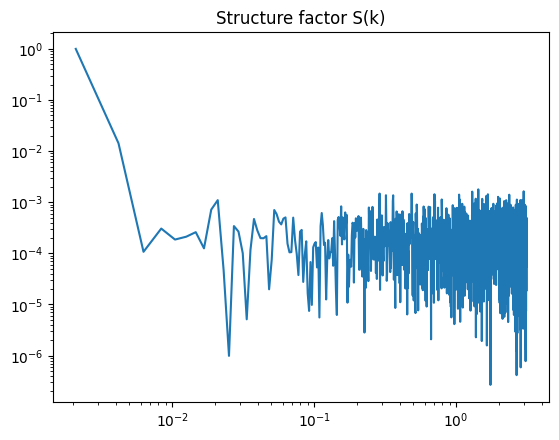

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- FFT ---
rho_fluct = rho - rho.mean(axis=1, keepdims=True)
rho_mean = np.mean(rho_fluct, axis=0)
rho_mean[np.argmax(rho_mean)] = 0

rhok = np.fft.fft(rho_mean)
Sk = np.abs(rhok)**2 / rho.shape[1]

ks = 2*np.pi*np.fft.fftfreq(rho.shape[1])

# --- remove k=0 for physics ---
mask = ks > 0
k = ks[mask]
S = Sk[mask]

# --- reorder for plotting ---
idx = np.argsort(k)
k = k[idx]
S = S[idx]

# --- normalize for shape analysis ---
S_norm = S / S.max()

# =========================================================
# 1. FIND PEAK POSITION (detect phase separation signature)
# =========================================================
k_peak = k[np.argmax(S)]

print("k_peak =", k_peak)

# =========================================================
# 2. SMALL-k FIT (hydrodynamic regime)
# S(k) ≈ A / (1 + ξ² k²)
# =========================================================
fit_mask = k < 0.1 * np.max(k)

coef = np.polyfit(k[fit_mask]**2, 1/S[fit_mask], 1)
xi = np.sqrt(coef[0])

print("correlation length ξ ≈", xi)

# =========================================================
# 3. CHECK FOR PHASE SEPARATION
# =========================================================
if k_peak > 0.1 * np.max(k):
    print(">>> Finite-k peak detected → phase separation / pattern formation likely")
else:
    print(">>> No finite-k peak → homogeneous or critical fluctuations")

# =========================================================
# 4. POROD LAW CHECK (high-k tail)
# S(k) ~ k^{-n}
# =========================================================
highk = k > 0.5 * np.max(k)

logk = np.log(k[highk])
logS = np.log(S[highk])

slope = np.polyfit(logk, logS, 1)[0]

print("high-k slope ≈", slope)

# =========================================================
# 5. PLOTS
# =========================================================
plt.figure()
plt.plot(k, S_norm)
plt.xscale("log")
plt.yscale("log")
plt.title("Structure factor S(k)")
plt.show()

Bare rho average

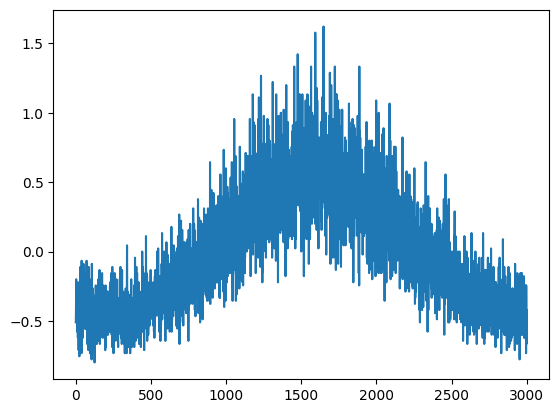

In [20]:
rho_mean = np.mean(rho_fluct, axis=0)
rho_mean[np.argmax(rho_mean)] = 0

plt.plot(rho_mean)

bare rhok (from bare average)

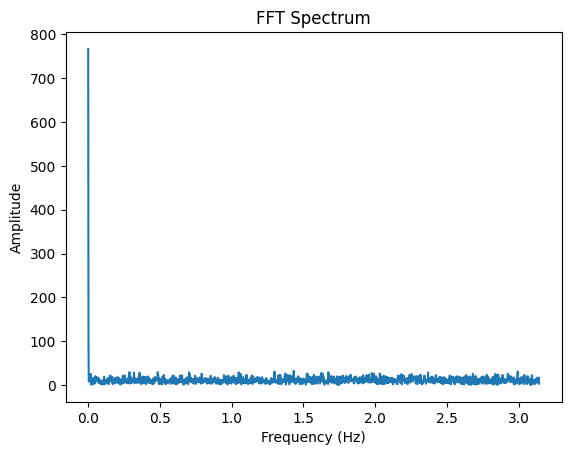

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Example signal: sum of two sine waves
t = np.linspace(0, 1, 1000, endpoint=False)
f = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)

# Compute FFT
F = np.fft.fft(rho_mean)

# Frequency axis
freqs = np.fft.fftfreq(3000, d=0.5/np.pi)

# Take only positive frequencies
mask = freqs > 0

plt.plot(freqs[mask], np.abs(F)[mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Spectrum")
plt.show()